Generation 1, Best Fitness: 0.5063749938646845
Generation 2, Best Fitness: 0.5129420654167093
Generation 3, Best Fitness: 0.5293202590060627
Generation 4, Best Fitness: 0.5293202590060627
Generation 5, Best Fitness: 0.5293202590060627
Generation 6, Best Fitness: 0.5293202590060627
Generation 7, Best Fitness: 0.5309763402393669
Generation 8, Best Fitness: 0.5309763402393669
Generation 9, Best Fitness: 0.5309763402393669
Generation 10, Best Fitness: 0.5309763402393669
Generation 11, Best Fitness: 0.5309763402393669
Generation 12, Best Fitness: 0.5372148499913066
Generation 13, Best Fitness: 0.5372148499913066
Generation 14, Best Fitness: 0.5396588583103967
Generation 15, Best Fitness: 0.5396588583103967
Generation 16, Best Fitness: 0.5443630780628005
Generation 17, Best Fitness: 0.5443630780628005
Generation 18, Best Fitness: 0.5443630780628005
Generation 19, Best Fitness: 0.5443630780628005
Generation 20, Best Fitness: 0.5443630780628005
Generation 21, Best Fitness: 0.5451648105395306
G

<Figure size 1200x800 with 0 Axes>

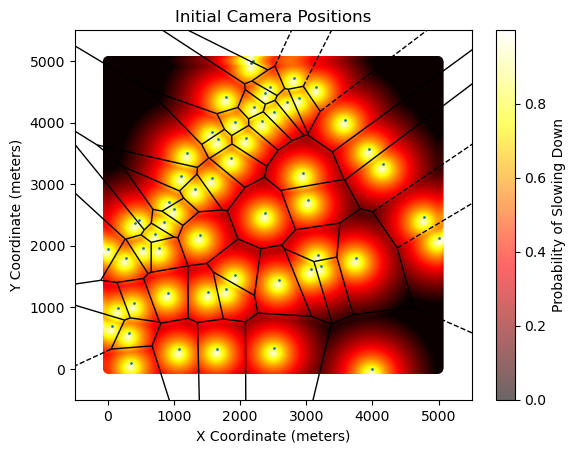

Initial Average Coverage Probability: 0.3893391060382403


<Figure size 1200x800 with 0 Axes>

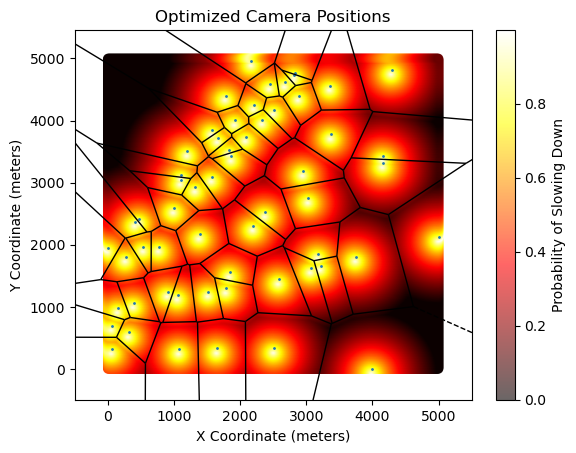

Optimized Average Coverage Probability: 0.4255293652704235

Solution Improvement: 0.09295305473020907
0.19604451997741756

There is no statistically significant difference in the means of the initial and final probabilities.


In [27]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import wilcoxon

# Record the start time
start_time = time.time()

# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 1000


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]


# Initialize parameters
population_size = 50
num_generations = 300
mutation_base_rate = 0.01
crossover_rate = 0.7  # Not used in the diversified crossover
tournament_size = 5
num_parents = population_size // 2
early_stopping_rounds = 20
no_improvement_stretch = 0
best_fitness = 0

# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    default_probability = 0.1  # This could be adjusted based on your system's minimum expected probability

    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if region != [] and -1 not in region:
            vertexes = vor.vertices[region]
            mask = np.all(np.logical_and(vertexes >= 0, vertexes <= area_size), axis=1)
            if np.any(mask):
                cell_points = grid_points[np.all(np.logical_and(grid_points >= vertexes.min(axis=0), grid_points <= vertexes.max(axis=0)), axis=1)]
                if len(cell_points) > 0:
                    cell_distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                    cell_probabilities = probability_of_slowing(np.min(cell_distances, axis=1))
                    voronoi_coverage.append(np.mean(cell_probabilities))
                else:
                    voronoi_coverage.append(default_probability)
            else:
                voronoi_coverage.append(default_probability)
        else:
            voronoi_coverage.append(default_probability)

    if return_individual:
        return voronoi_coverage
    else:
        mean_coverage = np.mean(voronoi_coverage)
        #print(f"Debug: Coverage for camera positions: {mean_coverage}")
        return mean_coverage


def adaptive_mutation(child, base_mutation_rate, generation):
    mutation_rate = base_mutation_rate * (1 + np.exp(-0.05 * generation))
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = np.random.uniform(0, max(area_size), 2)
    return child


def crossover(parents, method='uniform'):
    offspring = []
    for i in range(0, len(parents), 2):
        parent1 = parents[i]
        parent2 = parents[i+1] if i+1 < len(parents) else random.choice(parents)
        child1, child2 = parent1.copy(), parent2.copy()
        
        if method == 'single-point':
            cp = np.random.randint(1, len(parent1))
            child1, child2 = np.concatenate([parent1[:cp], parent2[cp:]]), np.concatenate([parent2[:cp], parent1[cp:]])
        elif method == 'two-point':
            cp1, cp2 = sorted(np.random.choice(range(1, len(parent1)), 2, replace=False))
            child1 = np.concatenate([parent1[:cp1], parent2[cp1:cp2], parent1[cp2:]])
            child2 = np.concatenate([parent2[:cp1], parent1[cp1:cp2], parent2[cp2:]])

        offspring.extend([child1, child2])
    return offspring

def fitness_function(individual, grid_points, min_distance, penalty_scale=0.8):
    coverage = calculate_voronoi_coverage(grid_points, individual)
    penalty = 0
    num_pairs = 0

    # Calculate the reduction factor for each violating camera pair
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            distance = np.linalg.norm(individual[i] - individual[j])
            if distance < min_distance:
                penalty_reduction = (min_distance - distance) / min_distance
                penalty += penalty_reduction
                num_pairs += 1

    # Calculate average penalty if there are any violations
    if num_pairs > 0:
        average_penalty = penalty / num_pairs
        adjusted_coverage = coverage * (1 - penalty_scale * average_penalty)
    else:
        adjusted_coverage = coverage

    # Ensure fitness is non-negative
    fitness = max(0, adjusted_coverage)
    #print(f"Debug: Original Coverage {coverage}, Penalty {penalty}, Adjusted Coverage {adjusted_coverage}, Final Fitness {fitness}")
    return fitness




def initialize_population(pop_size, crash_points):
    population = []
    for _ in range(pop_size):
        np.random.shuffle(crash_points)
        population.append(crash_points.copy())
    return population

def calculate_fitness(population, grid_points, min_distance):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness_function(individual, grid_points, min_distance))
    return np.array(fitness_scores)

def tournament_selection(population, fitness_scores, num_parents):
    parents = []
    for _ in range(num_parents):
        indices = np.random.randint(len(population), size=tournament_size)
        best_index = indices[np.argmax(fitness_scores[indices])]
        parents.append(population[best_index].copy())
    return parents

def apply_crossover(parents):
    offspring = []
    for i in range(0, len(parents), 2):
        if i + 1 < len(parents):
            parent1 = parents[i]
            parent2 = parents[i + 1]
            if np.random.rand() < crossover_rate:
                crossover_method = 'single-point' if np.random.rand() < 0.5 else 'two-point'
                children = crossover([parent1, parent2], method=crossover_method)
                offspring.extend(children)
            else:
                offspring.extend([parent1, parent2])
        else:
            offspring.append(parents[i])
    return offspring

def apply_mutation(offspring, improvement_factor):
    for i in range(len(offspring)):
        offspring[i] = adaptive_mutation(offspring[i], mutation_base_rate, improvement_factor)
    return offspring

# Initialize population
population = initialize_population(population_size, scaled_crash_points)

# Main GA loop
for generation in range(num_generations):
    fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
    current_best = np.max(fitness_scores)
    
    if current_best > best_fitness:
        best_fitness = current_best
        no_improvement_stretch = 0
    else:
        no_improvement_stretch += 1
    
    if no_improvement_stretch >= early_stopping_rounds:
        print(f"Early stopping after {generation} generations.")
        break
    
    parents = tournament_selection(population, fitness_scores, num_parents)
    offspring = apply_crossover(parents)
    improvement_factor = (best_fitness - current_best) / best_fitness if best_fitness != 0 else 0
    offspring = apply_mutation(offspring, improvement_factor)
    population = parents + offspring

    print(f"Generation {generation + 1}, Best Fitness: {best_fitness}")

# Determine the best solution
final_fitness_scores = calculate_fitness(population, scaled_crash_points, min_distance)
best_index = np.argmax(final_fitness_scores)
best_solution = population[best_index]

# Print the final best solution and its fitness
print("Best Solution Fitness:", final_fitness_scores[best_index])

#-----------------------------------------------------------------------------------------------
def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    default_probability = 0.1  # This could be adjusted based on your system's minimum expected probability

    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if region != [] and -1 not in region:
            vertexes = vor.vertices[region]
            mask = np.all(np.logical_and(vertexes >= 0, vertexes <= area_size), axis=1)
            if np.any(mask):
                cell_points = grid_points[np.all(np.logical_and(grid_points >= vertexes.min(axis=0), grid_points <= vertexes.max(axis=0)), axis=1)]
                if len(cell_points) > 0:
                    cell_distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                    cell_probabilities = probability_of_slowing(np.min(cell_distances, axis=1))
                    voronoi_coverage.append(np.mean(cell_probabilities))
                else:
                    voronoi_coverage.append(default_probability)
            else:
                voronoi_coverage.append(default_probability)
        else:
            voronoi_coverage.append(default_probability)

    if return_individual:
        return voronoi_coverage
    else:
        mean_coverage = np.mean(voronoi_coverage)
        #print(f"Debug: Coverage for camera positions: {mean_coverage}")
        return mean_coverage
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points
# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

distances = pairwise_distances(grid_points, best_solution)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)
plot_voronoi(best_solution, probabilities, 'Optimized Camera Positions')
final_avg_probability = calculate_voronoi_coverage(grid_points, best_solution)
print(f"Optimized Average Coverage Probability: {final_avg_probability}")
final_probabilities = calculate_voronoi_coverage(grid_points, best_solution, return_individual=True)
print("")
print("Solution Improvement:",(final_avg_probability-initial_avg_probability)/initial_avg_probability)

data = {
        'Initial_X': scaled_crash_points[:, 0],
        'Initial_Y': scaled_crash_points[:, 1],
        'Initial_Probability': initial_probabilities,
        'Final_X': best_solution[:, 0],
        'Final_Y': best_solution[:, 1],
        'Final_Probability': final_probabilities
    }
comparison_df = pd.DataFrame(data)
# Perform the Wilcoxon signed-rank test
wilcoxon_test = wilcoxon(data['Initial_Probability'], data['Final_Probability'])
p_value = wilcoxon_test.pvalue

# Save to CSV
#comparison_output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V2/Providencia/Genetic Algorithm/G_A_Lin_HT.csv'  # Adjust the path as necessary
#comparison_df.to_csv(comparison_output_csv_path, index=False)

# Interpretation of the test result
print(p_value)
print("")
if p_value < 0.05:
    print("There is a statistically significant difference in the means of the initial and final probabilities.")
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Providencia/GA/G_A_Log_Provi_HT.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)

    print(f"Camera probabilities saved to {output_csv_path}")
    # Print the coordinates of the optimized camera positions
    print("Final Camera Positions (coordinates):")
    for index, position in enumerate(best_solution):
        print(f"Camera {index + 1}: (X: {position[0]:.2f}, Y: {position[1]:.2f})")

    # Convert optimized camera positions back to original coordinates
    original_camera_positions = scaler.inverse_transform(best_solution)
    print("Camera Positions in Longitude and Latitude:")
    for i, pos in enumerate(original_camera_positions):
        print(f"Camera {i + 1}: (X: {pos[0]:.2f}, Y: {pos[1]:.2f})")
    # Convert to DataFrame
    camera_positions_df = pd.DataFrame(original_camera_positions, columns=['X', 'Y'])

    # Save to CSV
    output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Providencia/GA/G_A_Log_Provi.csv'  # Adjust the path as necessary
    camera_positions_df.to_csv(output_csv_path, index=False)
else:
    print("There is no statistically significant difference in the means of the initial and final probabilities.")

In [ ]:
#Form 2